In [1]:
# import lib from others
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
import scipy.constants
from scipy.stats import norm      # convenient helper (optional)

In [3]:
plt.rcParams.update({'font.size': 14})

In [4]:
# choose a bin width
bin_width = 20

# build the edges from min to max
min_edge = 0
max_edge = 660
bin_edges = np.arange(min_edge, max_edge + bin_width, bin_width)

# LEMMOND spectrum

In [5]:
def pdf_theory(E_edges, theta_edges, P_mu, nu, inputcostheta):
    E_mu = np.sqrt(P_mu**2+m_mu**2)   # MeV (monochromatic)
    gamma = E_mu / m_mu
    beta  = np.sqrt(1 - 1/gamma**2)

    theta_c = 0.5*(theta_edges[:-1] + theta_edges[1:])   # centres
    E_c     = 0.5*(E_edges[:-1]    + E_edges[1:])

    theta_grid, E_grid = np.meshgrid(theta_c, E_c, indexing='ij')
    
    # variables
    x = 2*E_grid * gamma* (1 - beta*np.cos(theta_grid))/ m_mu 

    if nu == 'nu_mu':
        f = 2*x**2*(3-2*x) # muon neutrino
    else:
        f = 12*x**2*(1-x) # electron neutrino
    
    mask = (x>=0) & (x<=1)
    pdf = np.zeros_like(f)
    pdf[mask] = f[mask] *np.sin(theta_grid[mask]) / (m_mu*gamma*(1 - beta*np.cos(theta_grid[mask])))


    pdf = normalise(pdf, theta_edges, E_edges)

    print(pdf.shape, theta_edges.shape, E_edges.shape)
    
    if inputcostheta==1:
        theta_grid = np.cos(theta_grid)

    fig, ax = plt.subplots(figsize=(8,6))
    pcm = ax.pcolormesh(
        theta_grid, E_grid, pdf,
        cmap='viridis'
    )
    fig.colorbar(pcm, ax=ax, label='Density')
    ax.set_ylabel(fr'$E_\nu$ [MeV]')
    ax.set_xlabel(fr'$\theta$ [rad]')
    if inputcostheta==1:
        ax.set_xlim(1,0)
            
    return pdf

In [6]:
m_mu = 105.658 # MeV

def normalise(pdf, theta, E):
    dtheta = np.abs(np.diff(theta)[:, None])
    dE = np.diff(E)[None, :]
    area = dtheta*dE
    print(np.sum(pdf*area))
    norm_pdf = pdf/(np.sum(pdf*area))
    print(np.sum(norm_pdf*area))
    return norm_pdf

def normalise1D(pdf, E):
    dE = np.diff(E)[None, :]
    area = dE
    norm_pdf = pdf/(np.sum(pdf*area))
    print(np.sum(norm_pdf*area))
    return norm_pdf

1.0068707980642888
1.0
(999, 33) (1000,) (34,)
1.0077125010829628
1.0
(999, 33) (1000,) (34,)


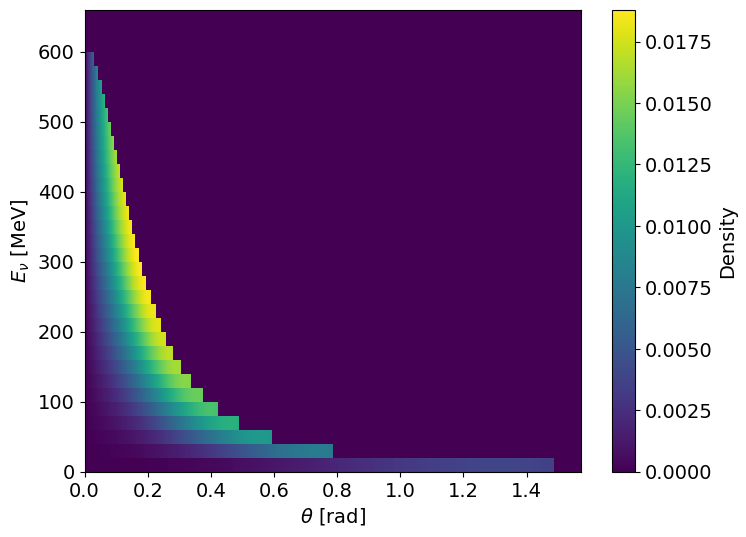

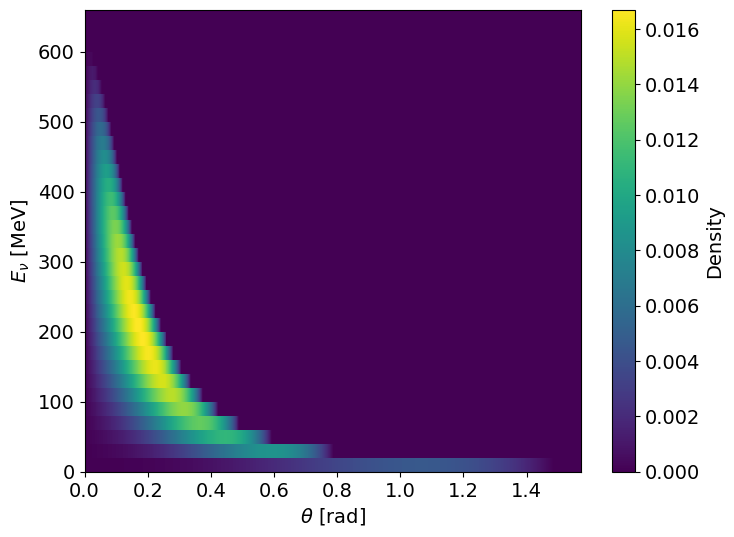

In [8]:
theta_edges = np.linspace(0, np.pi/2, 1000)        # rad
E_edges = np.arange(min_edge, max_edge + bin_width, bin_width)

pdf_nu_mu = pdf_theory(E_edges, theta_edges, 600, 'nu_mu', inputcostheta=0)
pdf_nu_e = pdf_theory(E_edges, theta_edges, 600, 'nu_e', inputcostheta=0)

In [9]:
theta_centers = 0.5*(theta_edges[:-1] + theta_edges[1:])
Ecenters = 0.5*(E_edges[:-1] + E_edges[1:])

In [13]:
# Length and radius 
R = 2.5

def LEMMOND_spectra2(counts, favour, s, d, data=[], MC=False):
    total_counts = []
    
    theta_grid, E_grid = np.meshgrid(theta_centers, Ecenters, indexing='ij')
    
    L = np.linspace(0, s, 10*s+1)
    
    print('theta range: 0 to ', np.arctan(R/(s+d-L[-1])) )
    
    for x in L:
        theta = np.arctan(R/(s+d-x))
        
        mask_theta = (theta_centers < theta)
    
        y = counts * mask_theta[:, None]           # still (N, M)
       
        total = np.trapezoid(y, x=theta_centers, axis=0)  # shape: (M,)
       
        total_counts.append(total) 
    
    Eweight = np.vstack(total_counts) # total_counts after summing angles at any point x 
    
    dmax = []
    
    # result = np.trapezoid(Eweight, L, axis=0)
    result = np.sum(Eweight, axis=0)
    print(result.shape)
    result = normalise1D(result, E_edges)
    
    plt.plot(Ecenters, result, label=fr'formula: {s,d}' )
    
    dmax.append(Ecenters[np.argwhere( result==max(result)).item() ])

    # from MC    
    if MC == True:
        plt.step(centers, data, where='mid', color='C1',
            label=fr'MC data ')
        
    plt.xlabel('E (MeV)')
    plt.ylabel(fr'$\{favour}$ density')
    plt.legend(ncol=1, )

theta range: 0 to  0.049958395721942765
(33,)
1.0


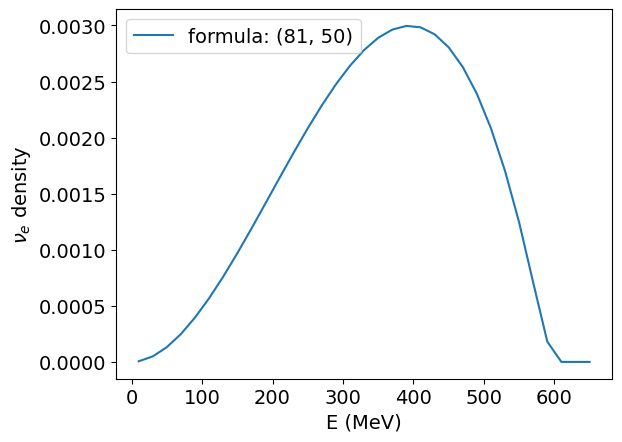

In [14]:
# plt.figure(figsize=(7,7))
LEMMOND_spectra2(pdf_nu_e, 'nu_e', s = 81, d =50, MC=0)